In [1]:
from nns.memorygraphs.foveated_memory_prototypes import FoveatedGraphMemory
mem = FoveatedGraphMemory(H=512, W=512)
mem.set_match_params(min_inliers = 10
                     , edge_preserve_threshold = 0.4
                     , inlier_distance_thresh = 4.0
                    #  , score_weights = None
                     )

from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
from trail.pic_tools import *
from trail.matrix_tools import *
import random
from trail.foveated_visualization1 import visualize_step

In [3]:
image_path = 'picture/OIP-C.jpg' 
# image_path = "d:/code/imgs/ILSVRClarge/Data/DET/train/ILSVRC2014_train_0003/ILSVRC2014_train_00030158.JPEG"
tensor, oringinal_image = image_to_tensor(image_path)
B, C, W, H = tensor.shape

retina_out = retina(tensor, center_x = -1, center_y = -1)
cropped = retina_out[5]
msfb_out = msbank(cropped)

In [ ]:
xL = int((512-H)/2) if H <= 512 else 0 
xR = int((512+H)/2) if H <= 512 else 512
yL = int((512-W)/2) if W <= 512 else 0 
yR = int((512+W)/2) if W <= 512 else 512
x = random.randint(xL+5, xR-5)
y = random.randint(yL+5, yR-5)
current_fix = (x, y)
print(current_fix)

res = mem.run_one_step(retina_out, msfb_out, current_fix, max_search_radius=16)
print(res['mode'], res['matched'])

(139, 152)
Matching..., search_radius =  8
Matching..., search_radius =  16
Match Failed, Learning
Looking at (139.0, 152.0)


(318, 183)


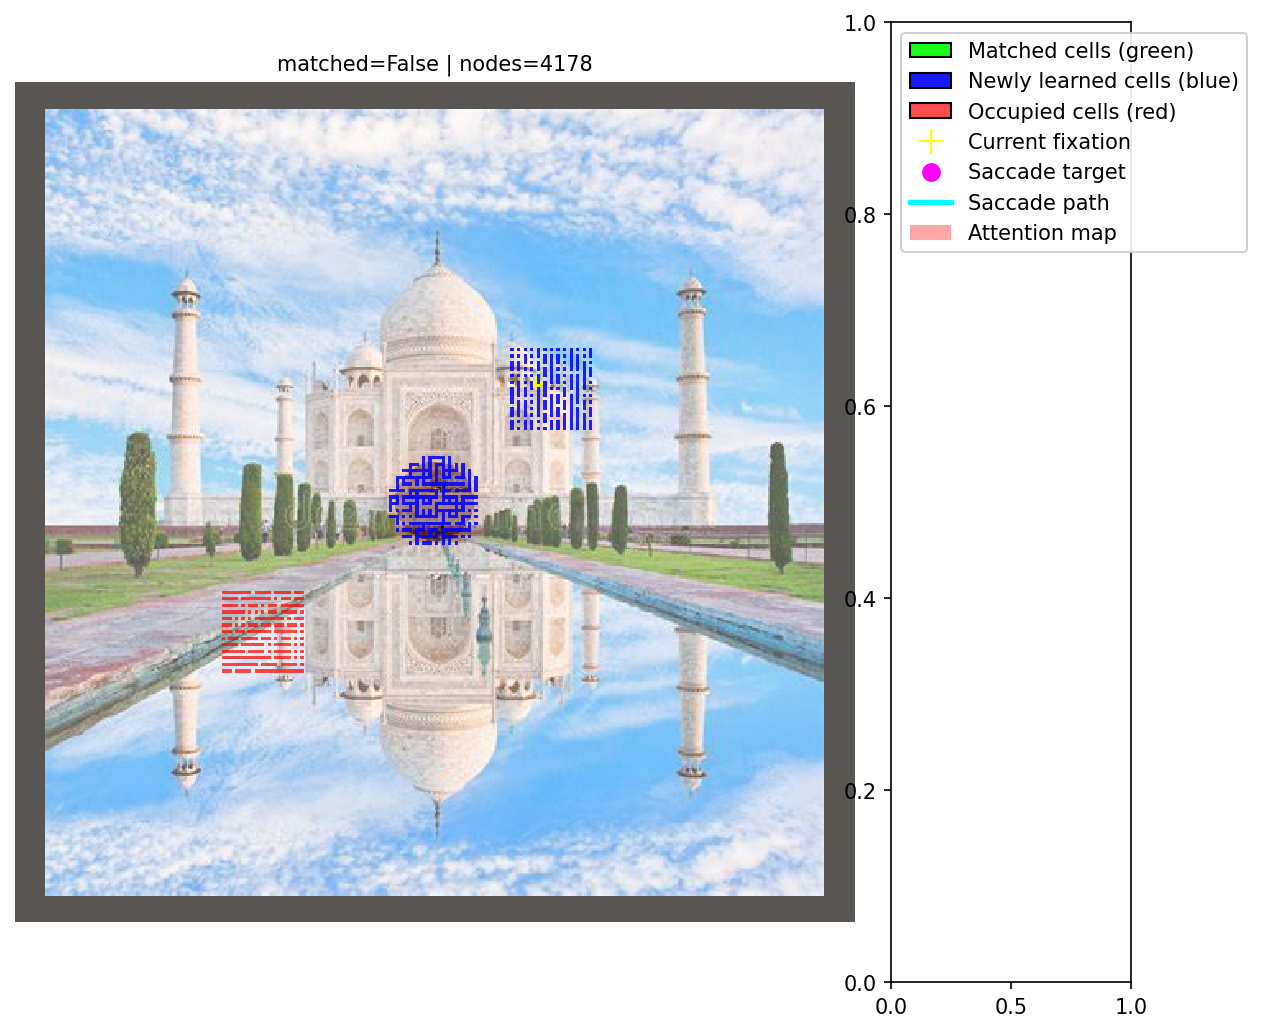

In [7]:
print(current_fix)
visualize_step(cropped, mem, res, current_fix= current_fix)